## Creating confidence from mixing weights

Previously, we have done some experiments on bootstrapping the `z` values to create confidence intervals. But as an afterthought, is might be much easier and also more accurate to create the confidence intervals from the mixing weights directly, as they are not binary and naturally have a distribution so 

### First, we load in the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
plt.style.use('smaller.mplstyle')


# Load the data
names = ["10kb", "50kb", "100kb"]
resolutions = [10000, 50000, 100000]
dfs = {}
for name,resolution in zip(names, resolutions):

    y = pd.Series(pd.read_csv(f"../data/eigs/sperm_X.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
    x = pd.Series(np.arange(0,y.shape[0])*resolution)

    dfs[name] = pd.DataFrame({"start": x, "e1": y})
    dfs[name].dropna(inplace=True)


centromere = (57984683, 69396537)
small_arm = (0, centromere[0])
large_arm = (centromere[1], x.max())
q_small = "start >= @small_arm[0] and start <= @small_arm[1]"
q_large = "start >= @large_arm[0] and start <= @large_arm[1]"



In [2]:
# Example
dfs['50kb'].query(q_small)

,start,e1
56,2800000,-0.075775
57,2850000,-0.419196
58,2900000,-0.154143
59,2950000,-0.280683
60,3000000,-0.305154
...,...,...
1155,57750000,-0.103347
1156,57800000,0.109004
1157,57850000,0.174414
1158,57900000,0.209500


## Load the traces

### No bootstrapping

We actually don't have to bootstrap now, as the mixing weights are not binary, but continuous. So we can just use the distribution of the mixing weights to create confidence intervals.

In [ ]:
import numpy as np
import arviz as az

trace_z = az.from_netcdf(f"../results/traces/09_hi_res_z_trace.nc")
trace_w = az.from_netcdf(f"../results/traces/09_hi_res_w_trace.nc")

w_stack_z = trace_z.posterior.w.stack(
   sample=["chain", "draw"]
)
w_stack_w = trace_w.posterior.w.stack(
    sample=["chain", "draw"]
)


In [17]:
display(
    trace_z,
    trace_w)

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [4]:
display(w_stack_z, 
        w_stack_w
        )

<xarray.DataArray 'w' (pos: 14090, sample: 7000)> Size: 789MB
array([[0.49845098, 0.50111294, 0.48945723, ..., 0.48881979, 0.4894599 ,
        0.49213342],
       [0.49816196, 0.5019803 , 0.48748968, ..., 0.49117923, 0.48703943,
        0.48499938],
       [0.48781272, 0.4884788 , 0.47702008, ..., 0.4872484 , 0.47524927,
        0.48112328],
       ...,
       [0.96736838, 0.96009126, 0.93282615, ..., 0.87955505, 0.94455071,
        0.92770146],
       [0.96574187, 0.958804  , 0.93386224, ..., 0.88054368, 0.94882708,
        0.92749744],
       [0.96323328, 0.95588321, 0.93532339, ..., 0.87853707, 0.9478945 ,
        0.92126791]], shape=(14090, 7000))
Coordinates:
  * pos      (pos) int64 113kB 278 279 280 281 282 ... 15566 15567 15568 15569
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

<xarray.DataArray 'w' (pos: 14090, sample: 7000)> Size: 789MB
array([[0.48641143, 0.51238984, 0.47115868, ..., 0.49385294, 0.49182086,
        0.48407751],
       [0.48539492, 0.48930593, 0.48523049, ..., 0.50464468, 0.48622559,
        0.46640803],
       [0.46137445, 0.49248884, 0.46330888, ..., 0.48710699, 0.46480013,
        0.45597681],
       ...,
       [0.93313308, 0.96487256, 0.87432998, ..., 0.92870773, 0.89692899,
        0.92377598],
       [0.93442708, 0.96442398, 0.87611797, ..., 0.92184192, 0.88786764,
        0.93019565],
       [0.92954619, 0.96331541, 0.88092029, ..., 0.92938874, 0.89691093,
        0.92309399]], shape=(14090, 7000))
Coordinates:
  * pos      (pos) int64 113kB 278 279 280 281 282 ... 15566 15567 15568 15569
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

## Trace plots

(Takes a couple of minutes to run)

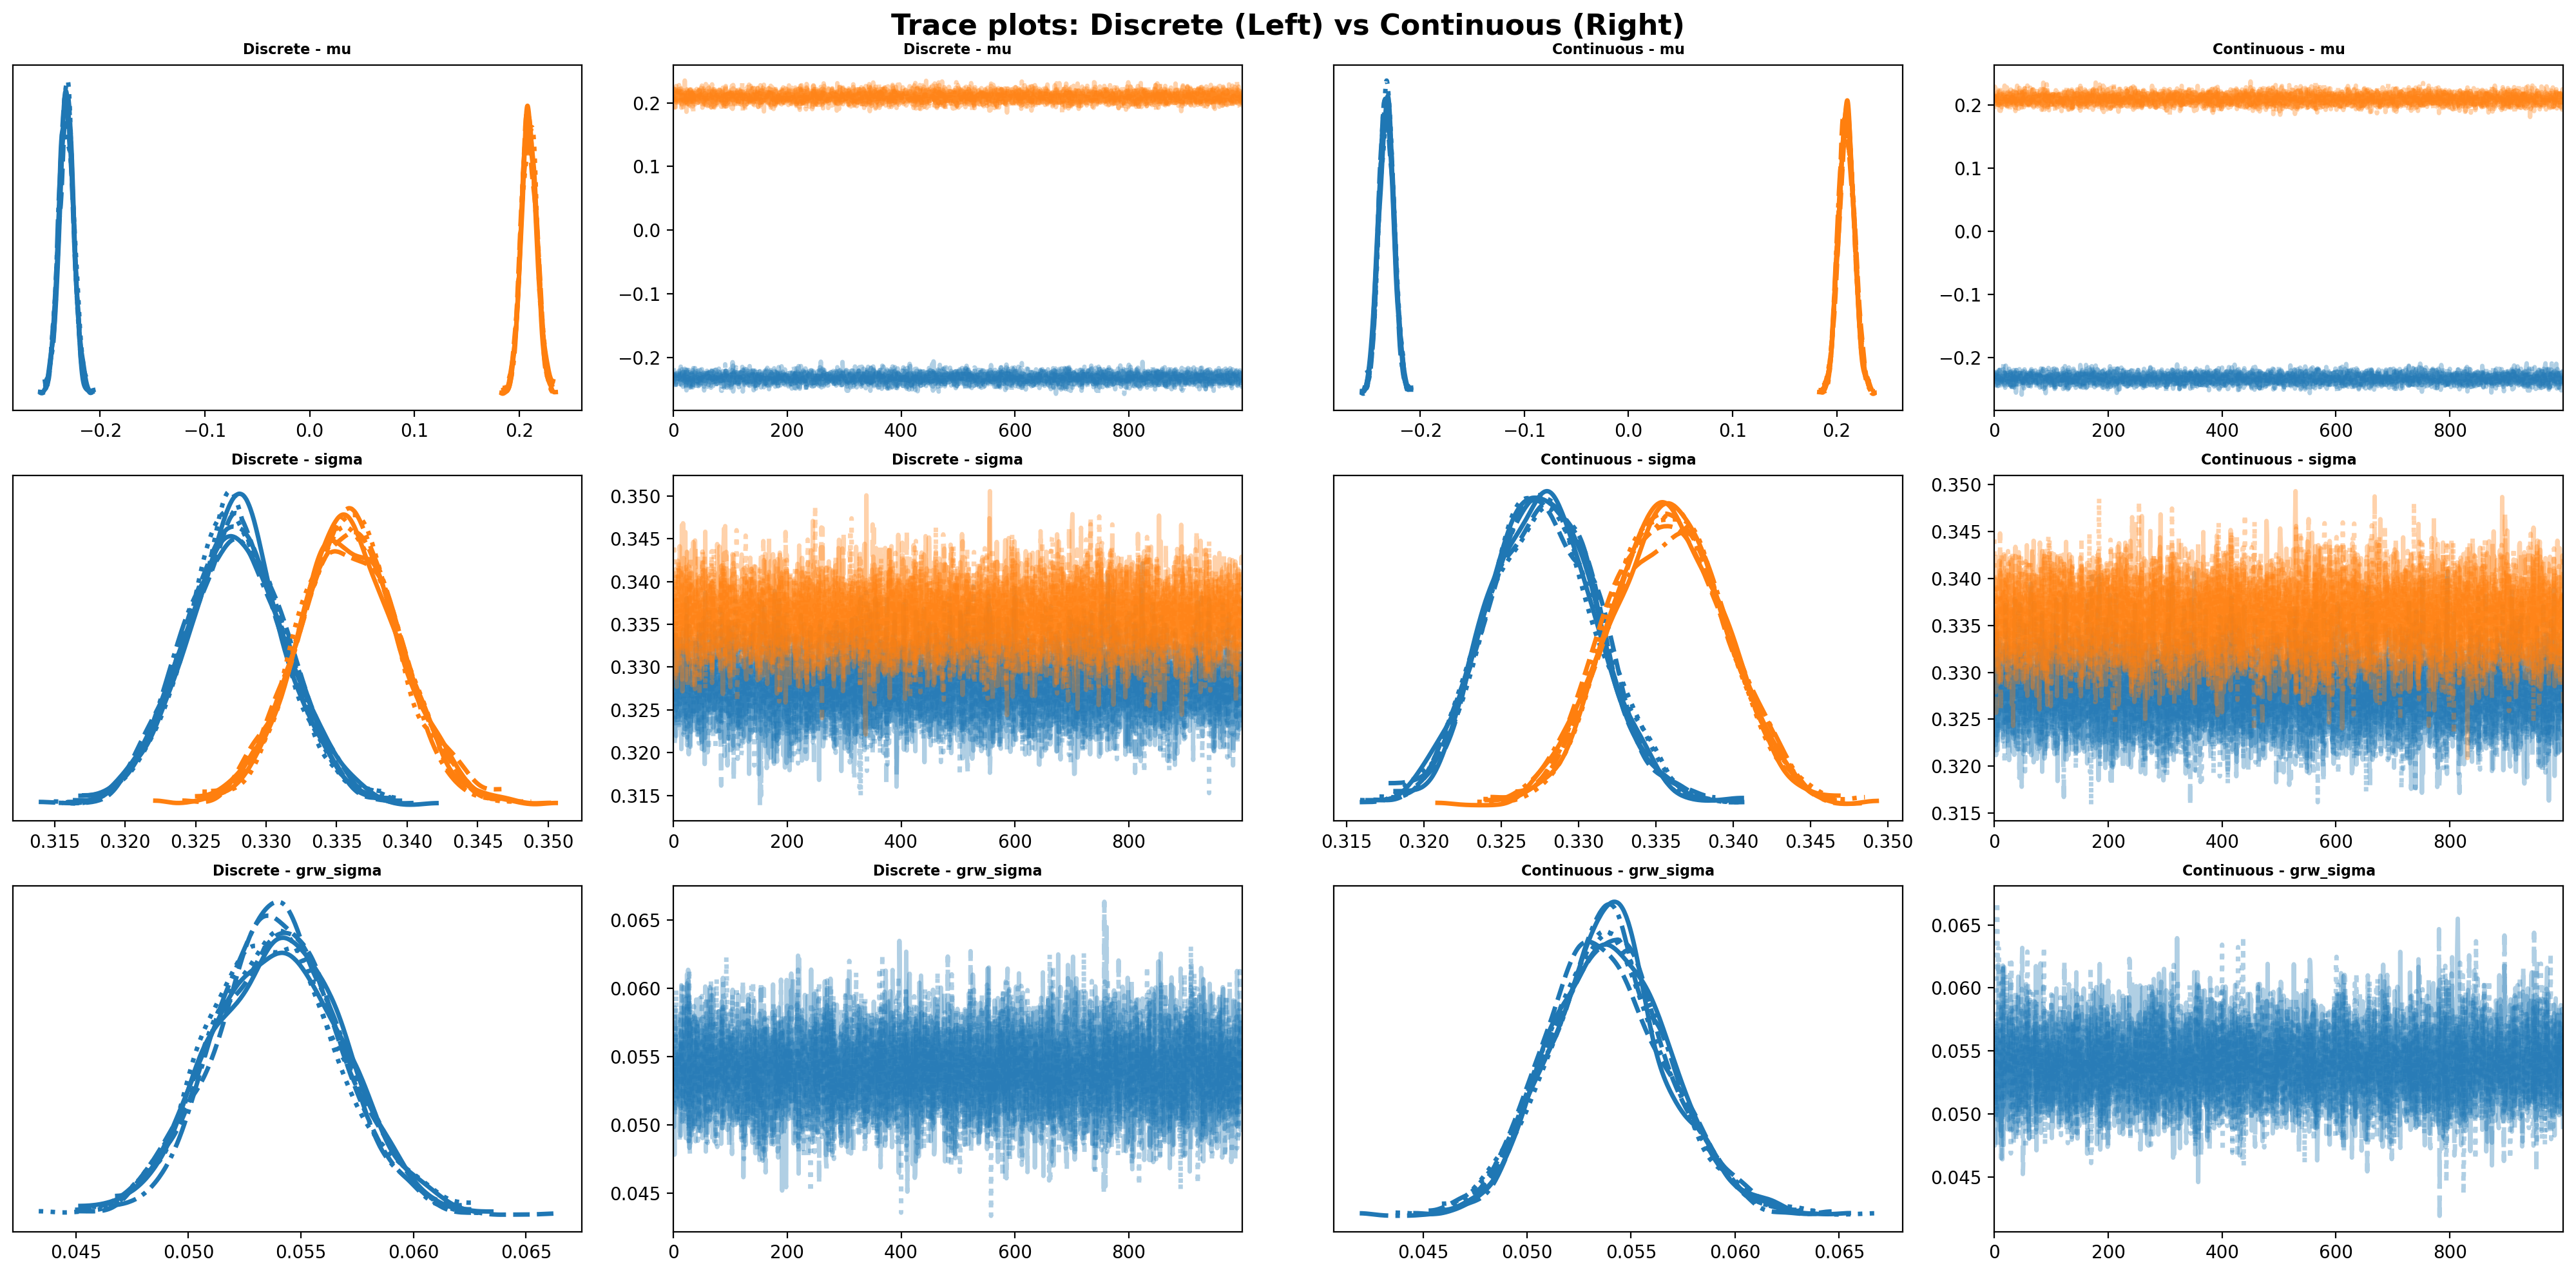

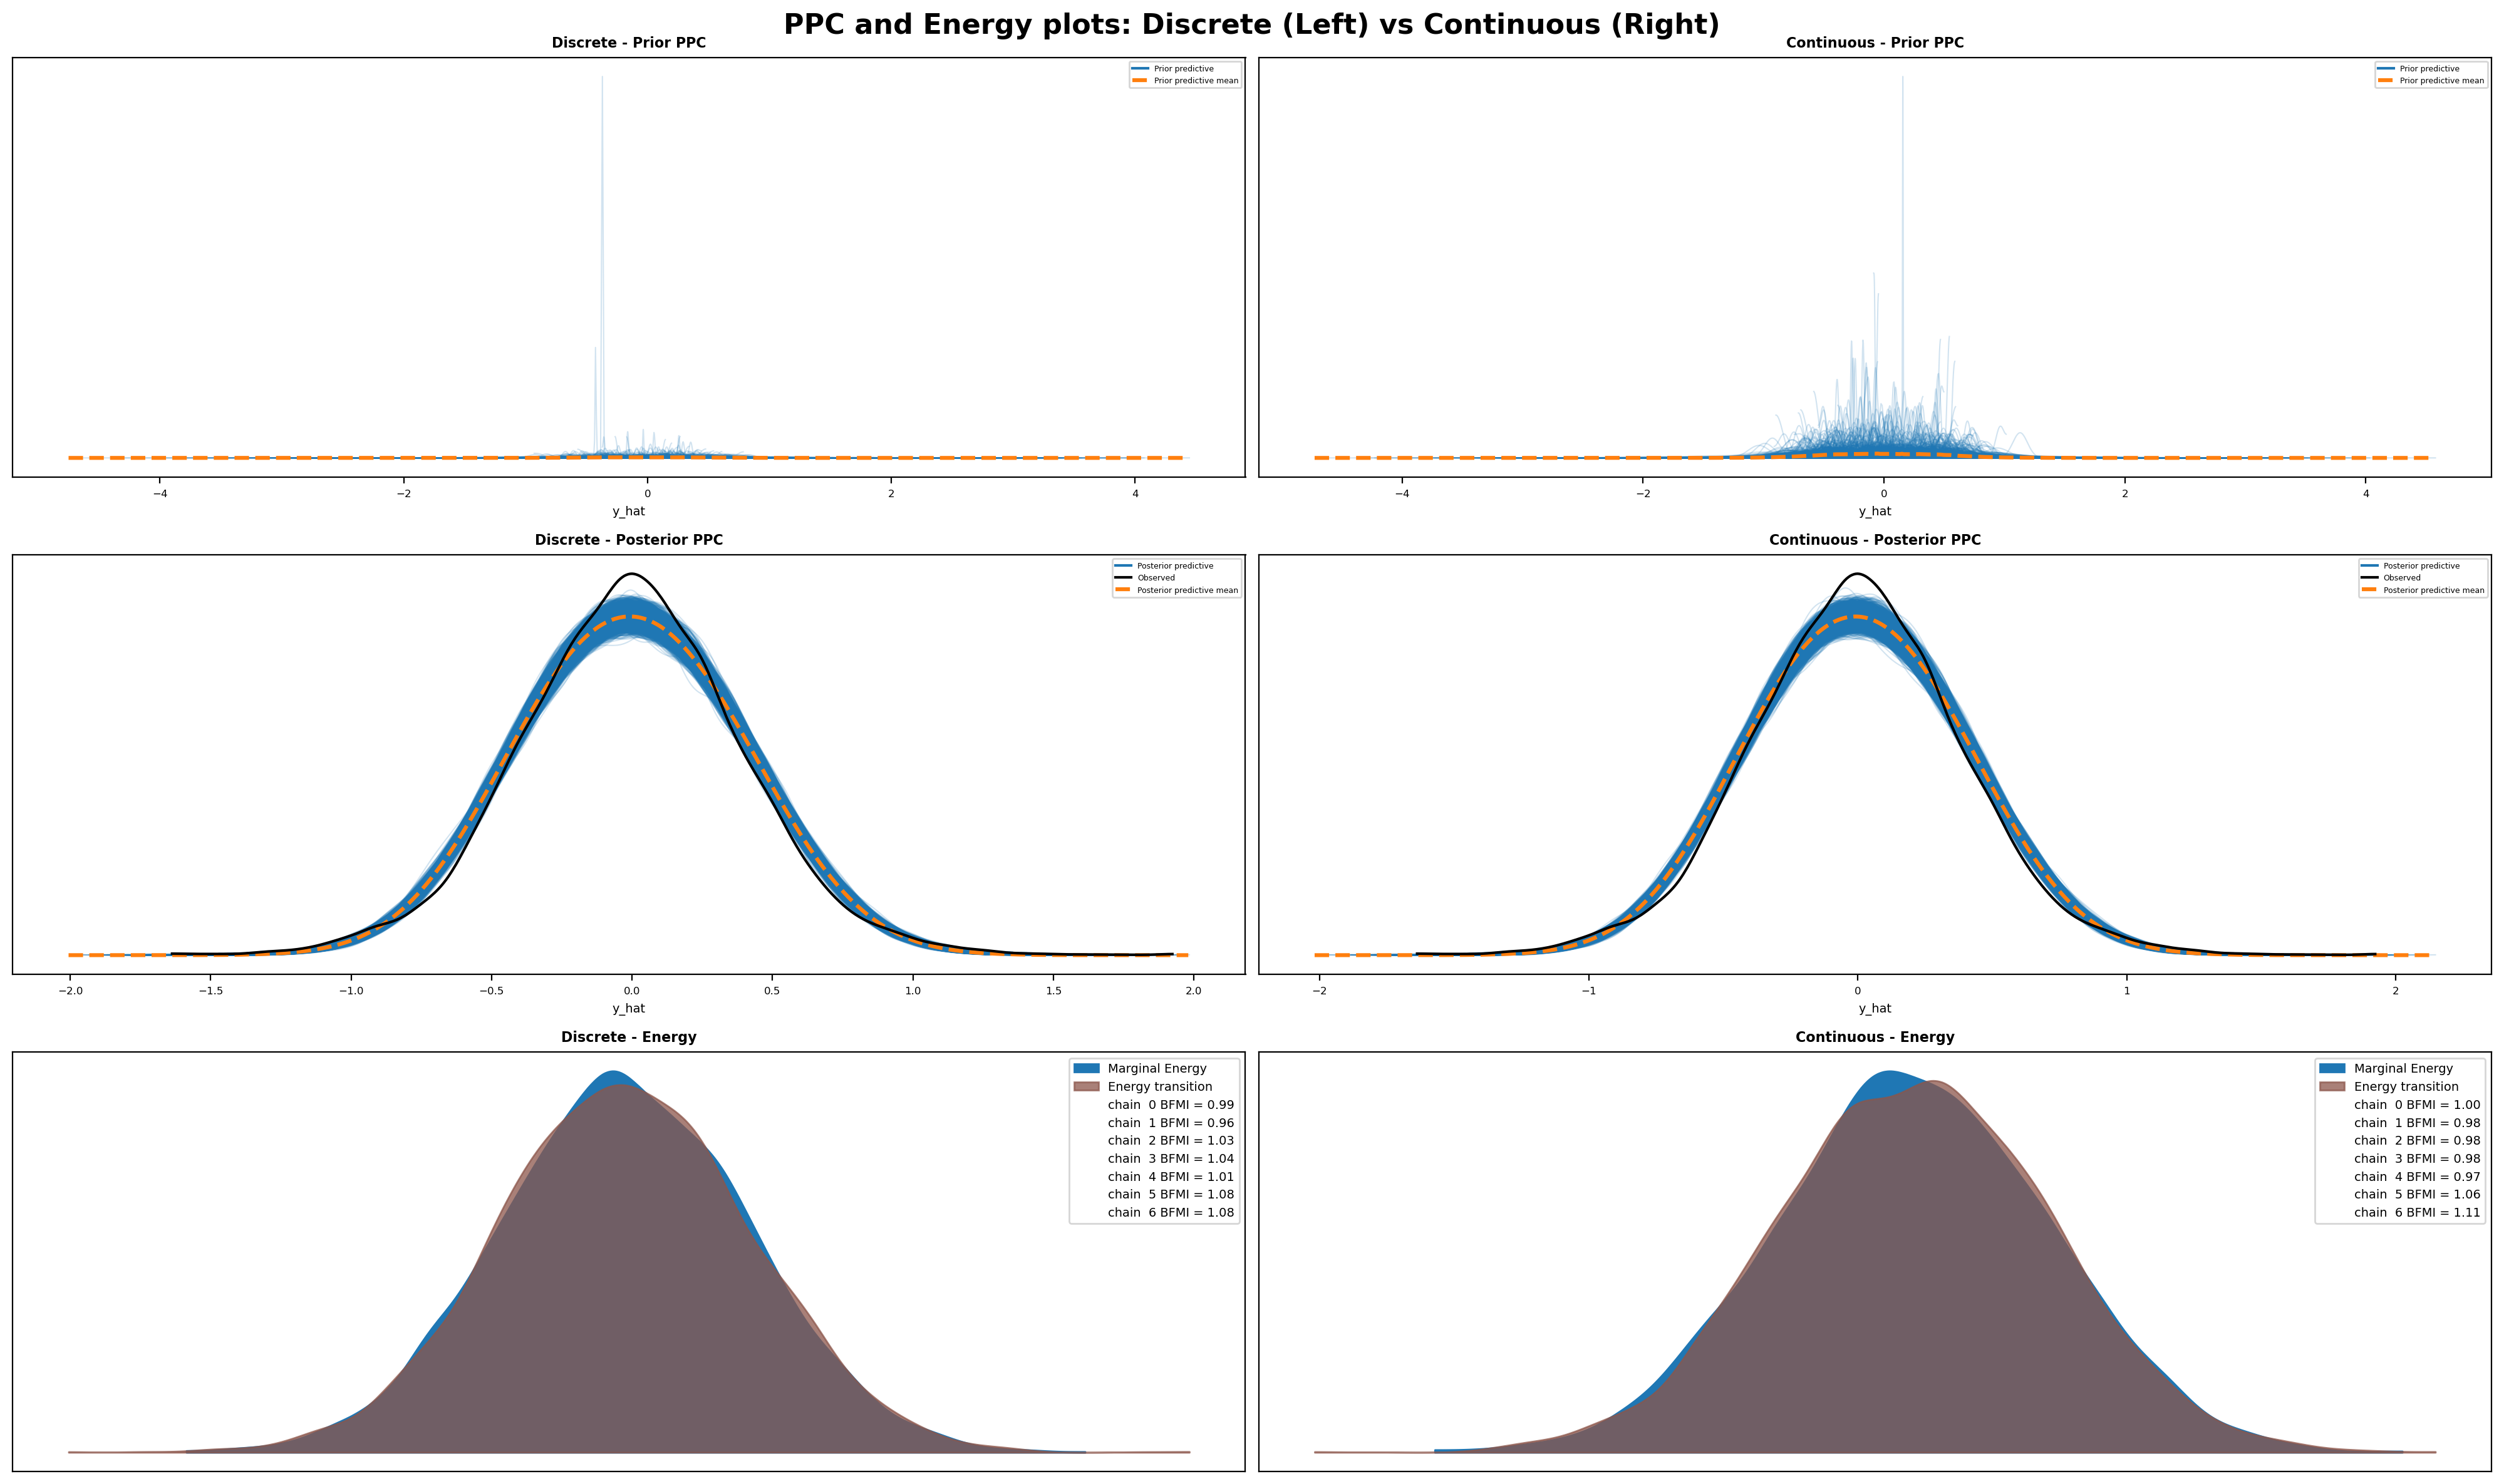

In [19]:
import arviz as az
import matplotlib.pyplot as plt

# Create figure with 2 columns for trace plots
f, axes = plt.subplots(3, 4, figsize=(20, 10))

# Discrete plots (left column - columns 0,1)
discrete_axes = axes[:, :2]
az.plot_trace(trace_z, var_names=["mu", "sigma", "grw_sigma"], compact=True, axes=discrete_axes)
discrete_axes[0, 0].set_title("Discrete - mu", fontweight='bold')
discrete_axes[0, 1].set_title("Discrete - mu", fontweight='bold')
discrete_axes[1, 0].set_title("Discrete - sigma", fontweight='bold')
discrete_axes[1, 1].set_title("Discrete - sigma", fontweight='bold')
discrete_axes[2, 0].set_title("Discrete - grw_sigma", fontweight='bold')
discrete_axes[2, 1].set_title("Discrete - grw_sigma", fontweight='bold')

# Continuous plots (right column - columns 2,3)
continuous_axes = axes[:, 2:]
az.plot_trace(trace_w, var_names=["mu", "sigma", "grw_sigma"], compact=True, axes=continuous_axes)
continuous_axes[0, 0].set_title("Continuous - mu", fontweight='bold')
continuous_axes[0, 1].set_title("Continuous - mu", fontweight='bold')
continuous_axes[1, 0].set_title("Continuous - sigma", fontweight='bold')
continuous_axes[1, 1].set_title("Continuous - sigma", fontweight='bold')
continuous_axes[2, 0].set_title("Continuous - grw_sigma", fontweight='bold')
continuous_axes[2, 1].set_title("Continuous - grw_sigma", fontweight='bold')

plt.suptitle("Trace plots: Discrete (Left) vs Continuous (Right)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Create figure with 2 columns for PPC and stats plots
f, axes = plt.subplots(3, 2, figsize=(20, 12))

# Discrete plots (left column)
az.plot_ppc(trace_z, var_names=["y_hat"], group="prior", ax=axes[0, 0])
axes[0, 0].set_title("Discrete - Prior PPC", fontweight='bold')

az.plot_ppc(trace_z, var_names=["y_hat"], ax=axes[1, 0])
axes[1, 0].set_title("Discrete - Posterior PPC", fontweight='bold')

az.plot_energy(trace_z, ax=axes[2, 0])
axes[2, 0].set_title("Discrete - Energy", fontweight='bold')

# Continuous plots (right column)
az.plot_ppc(trace_w, var_names=["y_hat"], group="prior", ax=axes[0, 1])
axes[0, 1].set_title("Continuous - Prior PPC", fontweight='bold')

az.plot_ppc(trace_w, var_names=["y_hat"], ax=axes[1, 1])
axes[1, 1].set_title("Continuous - Posterior PPC", fontweight='bold')

az.plot_energy(trace_w, ax=axes[2, 1])
axes[2, 1].set_title("Continuous - Energy", fontweight='bold')

plt.suptitle("PPC and Energy plots: Discrete (Left) vs Continuous (Right)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Do the arviz comparison

In [5]:
compare = az.compare({'Z':trace_z, 'W':trace_w}, ic='waic')
compare

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Z,0,-5657.522568,60.119836,0.000000,1.0,97.028875,0.000000,False,log
W,1,-5657.662226,60.121330,0.139658,0.0,97.055870,0.108694,False,log


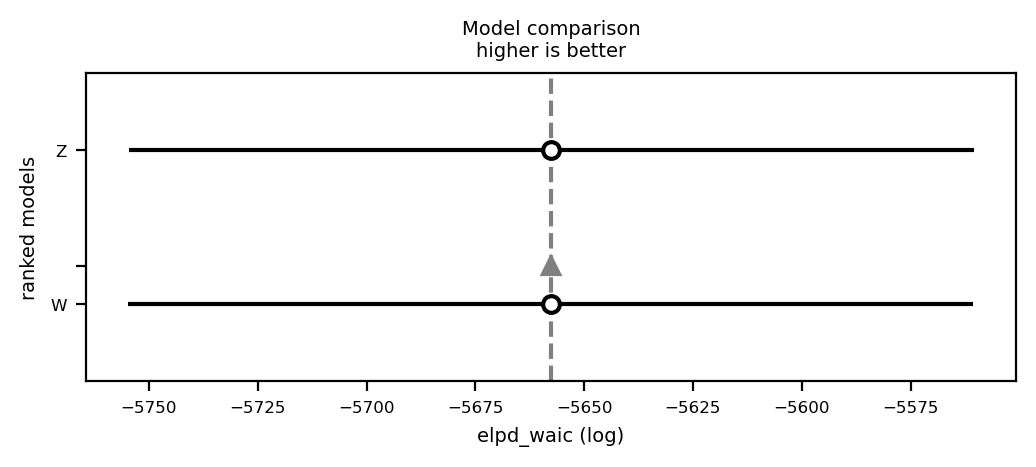

In [6]:
az.plot_compare(compare, plot_ic_diff=True);

The `weight` column can be losely interpreted as the probability of the model given the data, relative to the other model(s), but may not be directly useful when there are only two models, or the difference between $elpd$ is small. Here, the `elpd_diff` is almost 0, (documentation says that $\delta elpd < 4$ is considered small), so we can assume that in another with another random seed, the results could be reversed. Interestingly, the difference was bigger when using only the short chromosome arm, meaning the continuous model extracts more information from the data when eexpanding the data set. Where the discrete model seems to have a limit to the information it can extract.

In [7]:
# Use the trace directly  in stead of bootstrapping

w_mean = trace_z.posterior["w"].mean(dim=("chain", "draw"))  # shape (8714,)
w_ci_direct = trace_z.posterior["w"].quantile([0.05, 0.95], dim=("chain", "draw"))  # shape (2, 8714)
w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)  # shape (8714,)
w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)  # shape (8714,)


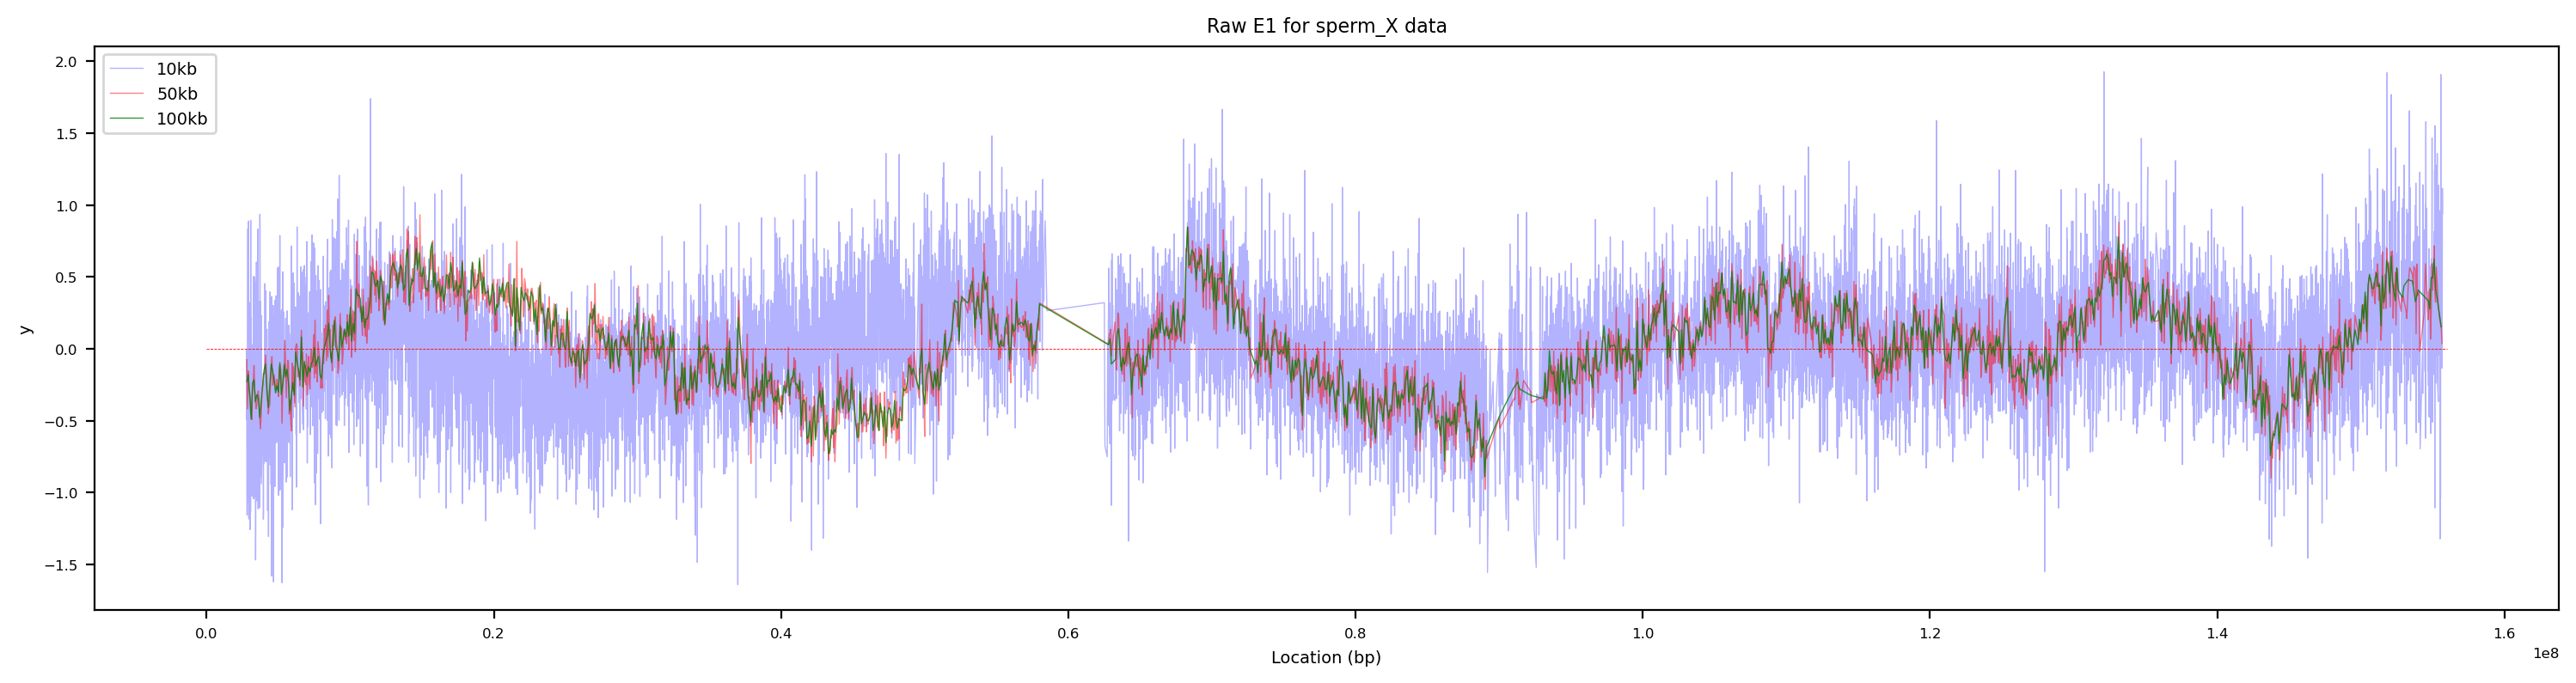

In [8]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


f, ax = plt.subplots(figsize=(15, 4))

ax.plot('start', 'e1', data = dfs['10kb'], linewidth=0.5, color="blue", label="10kb", alpha=0.3)
ax.plot('start', 'e1', data = dfs['50kb'], linewidth=0.5, color="red", label="50kb", alpha=0.5)
ax.plot('start', 'e1', data = dfs['100kb'], linewidth=0.5, color="green", label="100kb", alpha=0.8)

# Plot the 0.5 line
ax.hlines(0, min(x), max(x), color="red", linestyle="--", linewidth=0.3)

plt.ylabel("y")
plt.xlabel("Location (bp)")
plt.legend(loc='upper left')
plt.title("Raw E1 for sperm_X data")
plt.tight_layout()
plt.show()

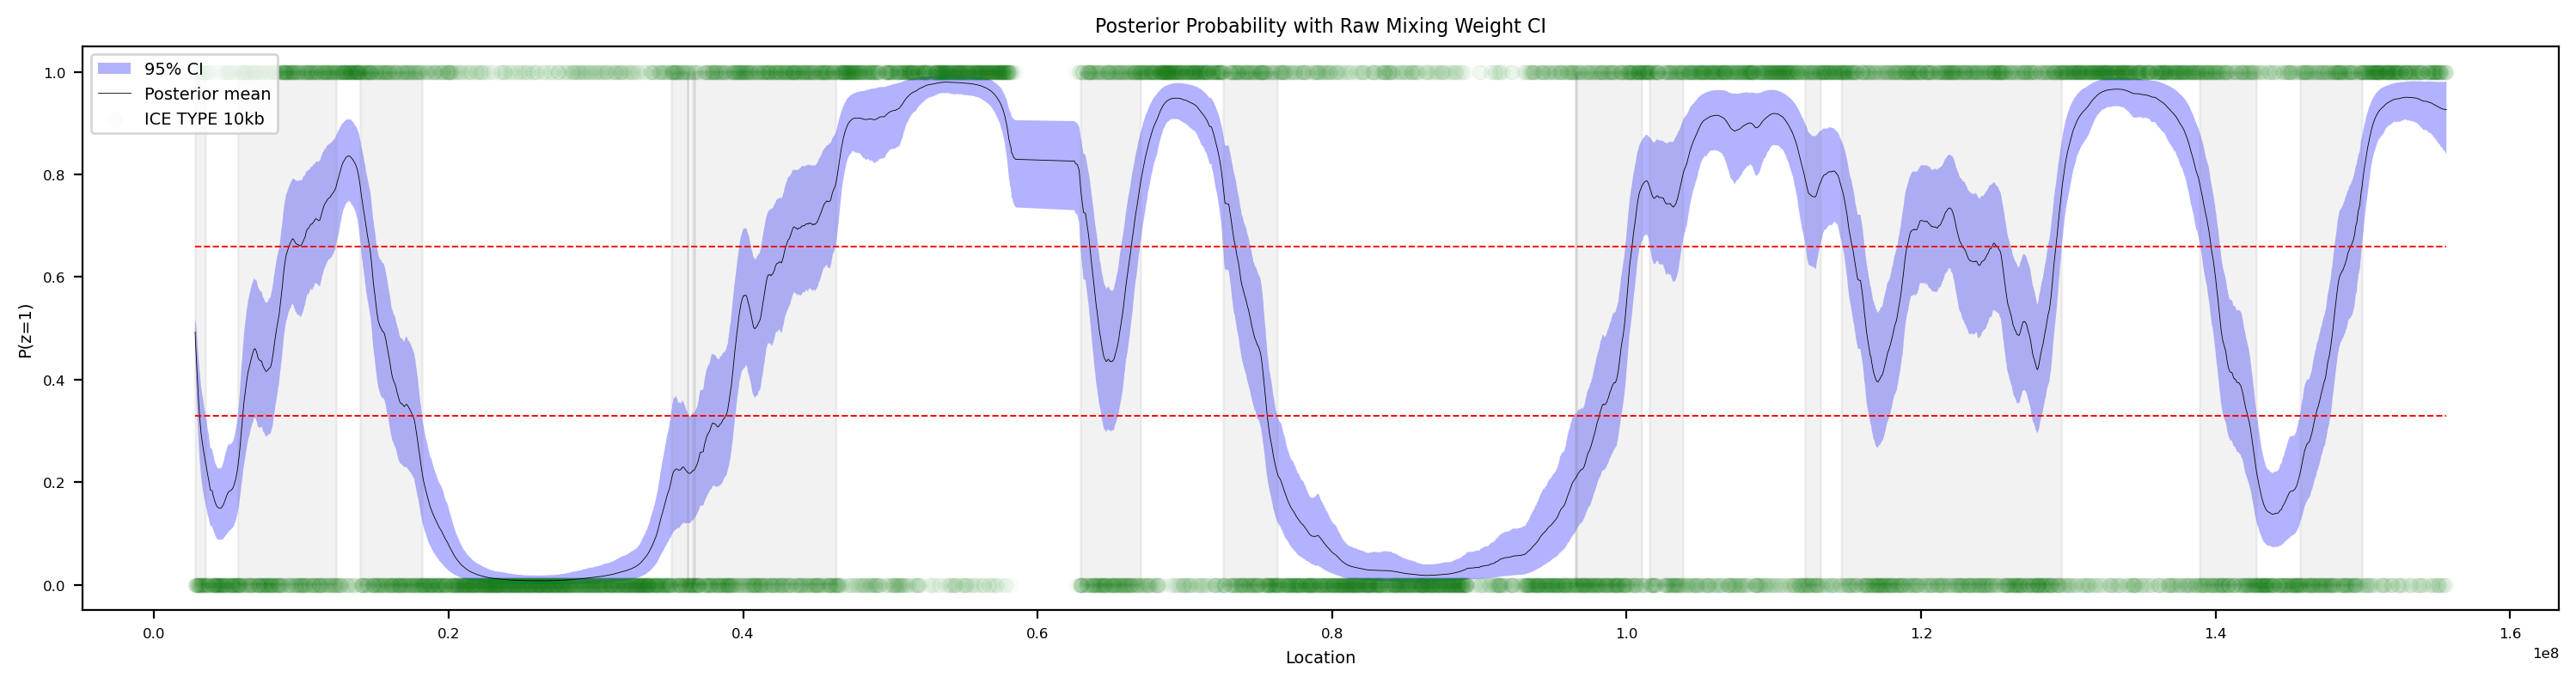

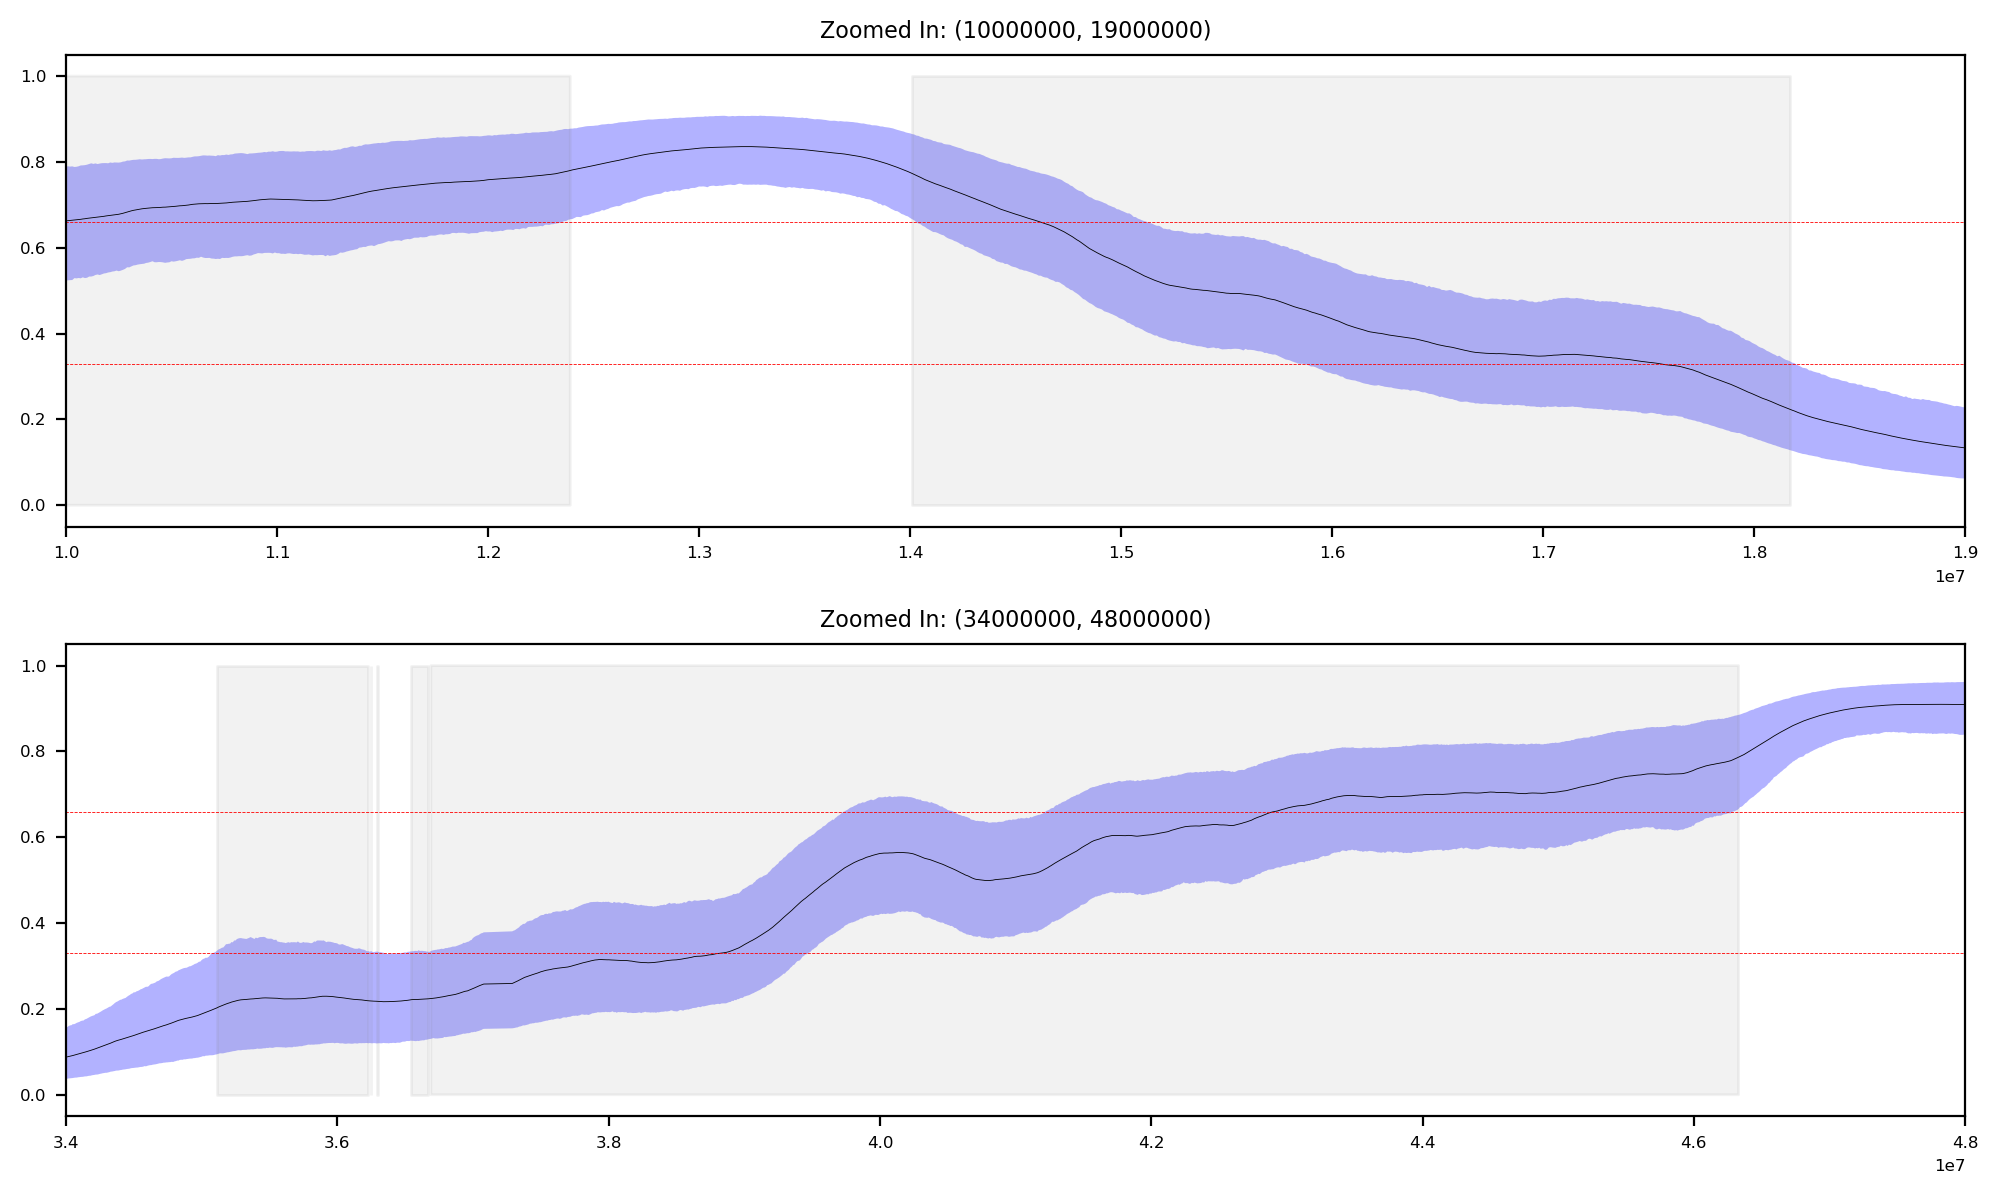

In [15]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

x = w_stack_z["pos"]*10000

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)),
    np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

# Compare e1 predictions
e1 = dfs['10kb']
hard_assign =  e1.e1 > 0

ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

ax.scatter(e1.start, hard_assign, label="ICE TYPE 10kb", color="green", linewidth=0.5, alpha=0.015)

# Plot the 0.5 line
ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.7)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend(loc='upper left')
plt.title("Posterior Probability with Raw Mixing Weight CI")
plt.tight_layout()
plt.show()

zooms = [(10_000_000,19_000_000), (34_000_000, 48_000_000)]

f, axs = plt.subplots(len(zooms), figsize=(10, 3*len(zooms)))

for i, zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        color="blue",
        ec='None'
    )

    # Grey band
    zax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
    color='gray')

    zax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)
    zax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    zax.set_xlim(zoom)
    zax.set_title(f"Zoomed In: {zoom}")

plt.tight_layout()
plt.show()



So, how can we visualize the density of confidence band? 

I will try to plot all the curves with a very low alpha to see if it looks nice.

In [10]:
w_stack_z.isel(sample=slice(0,100))

<xarray.DataArray 'w' (pos: 14090, sample: 100)> Size: 11MB
array([[0.49845098, 0.50111294, 0.48945723, ..., 0.47744952, 0.51304177,
        0.5054381 ],
       [0.49816196, 0.5019803 , 0.48748968, ..., 0.44867969, 0.50362417,
        0.50149913],
       [0.48781272, 0.4884788 , 0.47702008, ..., 0.43709984, 0.47988413,
        0.4909303 ],
       ...,
       [0.96736838, 0.96009126, 0.93282615, ..., 0.9197614 , 0.94851678,
        0.96471585],
       [0.96574187, 0.958804  , 0.93386224, ..., 0.9096326 , 0.94860942,
        0.96509552],
       [0.96323328, 0.95588321, 0.93532339, ..., 0.90972092, 0.94673456,
        0.96539125]], shape=(14090, 100))
Coordinates:
  * pos      (pos) int64 113kB 278 279 280 281 282 ... 15566 15567 15568 15569
  * sample   (sample) object 800B MultiIndex
  * chain    (sample) int64 800B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * draw     (sample) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99

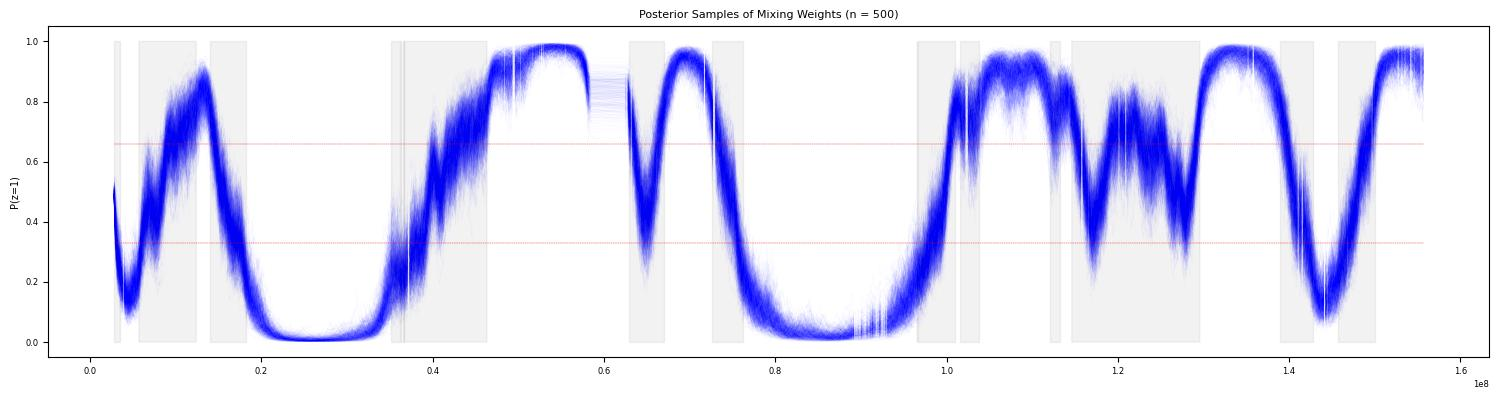

In [11]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')

w_subset = w_stack_z.isel(sample=slice(0, 500))  # Adjust the slice as needed

f, ax = plt.subplots(figsize=(15, 4))

for i in range(w_subset.shape[1]):
    ax.plot(x, w_subset[:,i], alpha=0.1, linewidth=0.05, color="blue")

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
ax.set_ylabel("P(z=1)")

plt.title(f"Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
plt.tight_layout()
plt.show()


## Translate into positional uncertainty

We translate the transitional regions (based on our CI rule) by counting the number of curves that cross the midpoint (0.5) between each position. Then we can summarize with statitics and establish the most likely transition. 

In [ ]:
import numpy as np
import xarray as xr

w_np = w_stack_z.values  # Convert to numpy array
w_da = w_stack_z # Use the xarray DataArray directly

# Set indices for w_np
w_idx = w_da['pos'].values

# Example find the correct position from the np index
np.where(w_idx == 14000)[0][0]


np.int64(12670)

In [163]:
# Try again

mask = (w_np > 0.5)  # plain ndarray
mask_next = np.roll(mask, shift=-1, axis=0)  # Shift mask down by one position
mask_curr = mask[:, :]

print(f"""
max.w_np: {w_np.max()}
mask_curr.shape: {mask_curr.shape}
       """)

cross_down = mask_curr & ~mask_next
cross_up = ~mask_curr & mask_next

# Or map the total crossings
crossings = mask_curr != mask_next

# Remove the last value where mask_next is wrapped from the first value
cross_down = cross_down[:-1, :]  # Remove the last row
cross_up = cross_up[:-1, :]  # Remove the last row
crossings = crossings[:-1, :]  # Remove the last row

# Sum the crossings across all samples to get the count of crossings at each position
crossing_counts = crossings.sum(axis=1)  # Sum across the sample dimension
cross_up_counts = cross_up.sum(axis=1)  # Sum across the sample dimension
cross_down_counts = cross_down.sum(axis=1)  # Sum across the sample dimension


# Calculate the density of crossings
crossing_density = crossing_counts / w_np.shape[1]
crossing_density_up = cross_up_counts / w_np.shape[1]
crossing_density_down = cross_down_counts / w_np.shape[1]

# Print shapes of all
print("Shape of w_np, mask:", w_np.shape)
print("Shape of crossing_counts:", crossing_counts.shape)
print("Shape of crossing_density:", crossing_density.shape)
print("Shape of crossing_density_up:", crossing_density_up.shape)
print("Shape of crossing_density_down:", crossing_density_down.shape)

df_crossing_density = pd.DataFrame({
    "bin": w_da["pos"].values[:-1],
    "crossing_prop_up": crossing_density_up,
    "crossing_prop_down": crossing_density_down
})
df_crossing_density.set_index("bin", inplace=True)
df_crossing_density
df_crossing_density.to_csv("../data/compartment_transitions.10kb.human_sperm_X.tsv", sep="\t")



max.w_np: 0.9985963607505536
mask_curr.shape: (14090, 7000)
       
Shape of w_np, mask: (14090, 7000)
Shape of crossing_counts: (14089,)
Shape of crossing_density: (14089,)
Shape of crossing_density_up: (14089,)
Shape of crossing_density_down: (14089,)


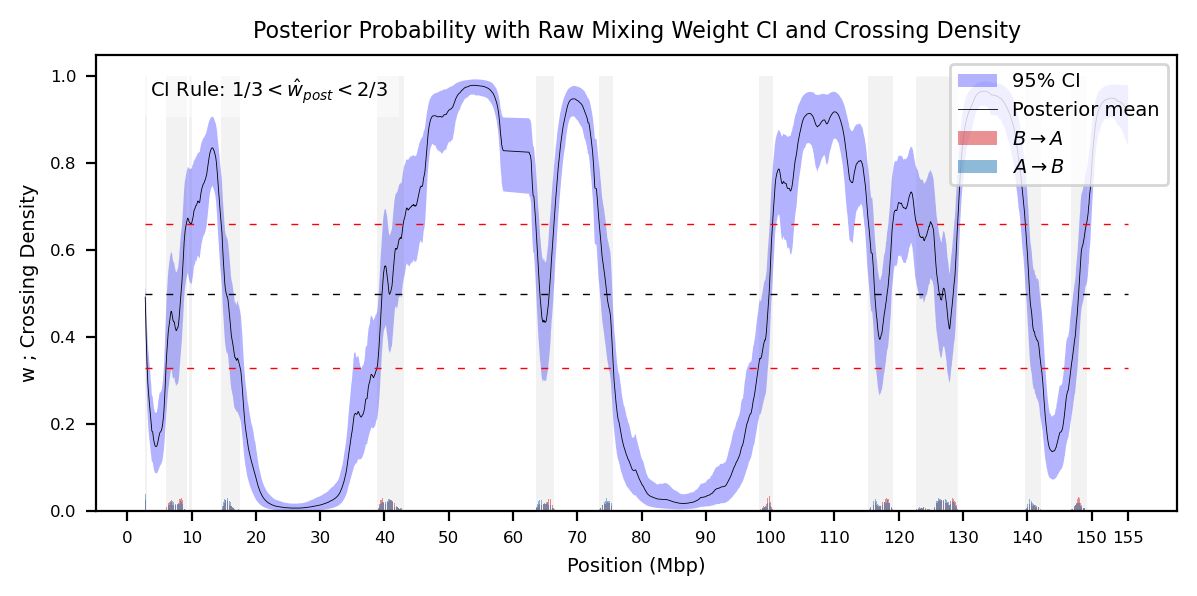

In [179]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

x = w_stack_z["pos"]

f, ax = plt.subplots(figsize=(6, 3))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_mean < 1/3) | (w_mean > 2/3)),
    np.nan
)

# Add the CI rule
ax.text(0.05, 0.95, "CI Rule: $1/3 < \\hat{w}_{post} < 2/3$", 
        transform=ax.transAxes, 
        fontsize=7, 
        verticalalignment='top', 
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray',
    ec='None'
    )

# Plot the posterior mean
ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines(0.5, min(x), max(x), color="black", linestyle=(0, (5, 10)), linewidth=0.5)

# # Plot the CI rules
ax.hlines([0.33,0.66], min(x), max(x), color="red", linestyle=(0, (5, 10)), linewidth=0.5)

# Plot the crossing counts
ax.bar(x[:-1], crossing_density_up, label="$B \\rightarrow A$", color="tab:red", linewidth=0.3, alpha=0.5)
ax.bar(x[:-1], crossing_density_down, label="$A \\rightarrow B$", color="tab:blue", linewidth=0.3, alpha=0.5)

#  make x-axis tick x 10000*1e-6 
ticks = np.arange(0, np.max(x), step=1000)
ticks = np.concatenate([ticks,[np.max(x)-1]])  # Ensure the last tick is included
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(tick/100)}" for tick in ticks])

plt.ylabel("w ; Crossing Density")
plt.xlabel("Position (Mbp)")
plt.legend(loc='upper right')
plt.title("Posterior Probability with Raw Mixing Weight CI and Crossing Density")
plt.tight_layout()
plt.show()

### Or make it a binned density plot

10000 bins on 6 inches of monitor is maybe not ideal

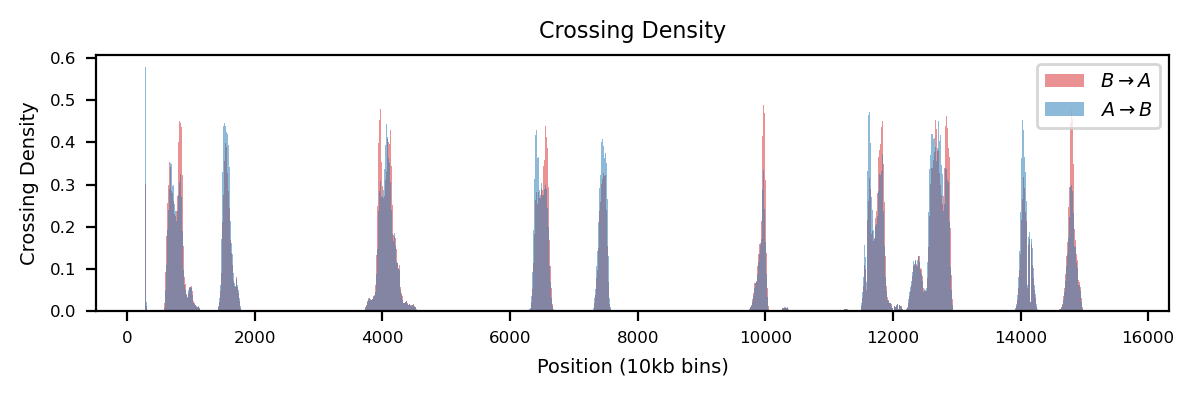

In [180]:
df_crossing_density = pd.read_csv("../data/compartment_transitions.10kb.human_sperm_X.tsv", sep="\t", index_col=0)

f,ax= plt.subplots()
ax.hist(df_crossing_density.index,
        weights=df_crossing_density.crossing_prop_up, bins=1000,
        label="$B \\rightarrow A$", color="tab:red", linewidth=0.3, alpha=0.5)
ax.hist(df_crossing_density.index, 
        weights=df_crossing_density.crossing_prop_down, bins=1000,
        label="$A \\rightarrow B$", color="tab:blue", linewidth=0.3, alpha=0.5)
ax.set_xlabel("Position (10kb bins)")
ax.set_ylabel("Crossing Density")
ax.set_title("Crossing Density")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [151]:
# Extract the transition intervals (transitions inside the CI rule)
# divide x_grey into continuous intervals

import numpy as np
import pandas as pd

def partition_intervals(arr):
    """
    Partition a numpy array of continuous number intervals into start/end pairs.
    
    Args:
        arr: numpy array with continuous intervals like [231, 232, 233, 454, 455, 456, ...]
    
    Returns:
        pandas DataFrame with 'start' and 'end' columns
    """
    if len(arr) == 0:
        return pd.DataFrame(columns=['start', 'end'])
    
    # Sort the array to ensure proper ordering
    arr = np.sort(arr)

    # Remove nan values
    arr = arr[~np.isnan(arr)]
    
    # Find where the differences between consecutive elements are > 1
    # This indicates the end of one interval and start of another
    diff = np.diff(arr)
    breaks = np.where(diff > 1)[0]
    
    # Create start and end indices for each interval
    start_indices = np.concatenate([[0], breaks + 1])
    end_indices = np.concatenate([breaks, [len(arr) - 1]])

    # Extract start and end values
    starts = arr[start_indices].astype(int)
    ends = arr[end_indices].astype(int)
    
    # Create DataFrame
    df = pd.DataFrame({
        'start': starts,
        'end': ends,
        'start_Mbp': (starts * 10000*1e-6).round(2),
        'end_Mbp': (ends * 10000*1e-6).round(2),
    })
    
    return df

def count_crossings_in_intervals(intervals_df, cross_up, cross_down):
    """
    Count crossings in each interval by indexing into boolean arrays.
    
    Args:
        intervals_df: DataFrame with 'start' and 'end' columns (indices)
        cross_up: boolean array indicating upward crossings
        cross_down: boolean array indicating downward crossings
    
    Returns:
        DataFrame with additional 'cross_up_count' and 'cross_down_count' columns
    """
    df = intervals_df.copy()
    
    cross_up_counts = []
    cross_down_counts = []
    
    for _, row in df.iterrows():
        start_idx = int(row['start'])
        end_idx = int(row['end'])

        # Map idx from w_idx
        start_idx = np.where(w_idx == start_idx)[0][0]
        end_idx = np.where(w_idx == end_idx)[0][0]
        
        # Count True values in each interval (inclusive)
        up_count = np.sum(cross_up[start_idx:end_idx + 1])
        down_count = np.sum(cross_down[start_idx:end_idx + 1])
        
        cross_up_counts.append(up_count)
        cross_down_counts.append(down_count)
    
    df['cross_up_count'] = cross_up_counts
    df['cross_down_count'] = cross_down_counts
    df['total_crossings'] = df['cross_up_count'] + df['cross_down_count']
    
    return df


In [152]:

inside_ci = x_grey.values

intervals = partition_intervals(inside_ci)
intervals = count_crossings_in_intervals(intervals, cross_up_counts, cross_down_counts)
intervals['length_bp'] = (intervals['end'] - intervals['start']) * 10000
(intervals 
 .filter(['start_Mbp', 'end_Mbp', 'length_bp', 'cross_up_count', 'cross_down_count', 'total_crossings'])
 .style.format({
    'start_Mbp': '{:,.2f}',
    'end_Mbp': '{:,.2f}',
    'length_bp': '{:,.0f}'
    })
)

,start_Mbp,end_Mbp,length_bp,cross_up_count,cross_down_count,total_crossings
0,2.78,3.07,"290,000",2202,4208,6410
1,6.03,6.57,"540,000",5409,3856,9265
2,6.59,6.92,"330,000",5457,5110,10567
3,6.94,8.45,"1,510,000",21719,19440,41159
4,8.47,9.25,"780,000",7141,4562,11703
5,9.59,10.07,"480,000",1288,1304,2592
6,14.58,17.33,"2,750,000",23657,30383,54040
7,17.35,17.49,"140,000",313,373,686
8,38.89,40.09,"1,200,000",17046,11681,28727
9,40.11,42.98,"2,870,000",31817,30475,62292
